In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.neighbors import KNeighborsClassifier #KNN - only 1D feature vectors
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

In [ ]:
# load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# shape of the data
print("X_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

#28x28=784 features



11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [ ]:
# flatten images
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)

# Normalize-prevents any pixel from overpowering others / fair distance claculation
x_train = x_train / 255.0
x_test = x_test / 255.0

print(x_train.shape)
print(y_train.shape)

#784 features


(60000, 784)
(60000,)


In [ ]:
# KNN model
k = 3
knn = KNeighborsClassifier(n_neighbors=k)

# fitting
knn.fit(x_train, y_train)

# predictingg oo test data
y_pred = knn.predict(x_test)


accuracy = accuracy_score(y_test, y_pred)
print("KNN Accuracy on this mnist data:", accuracy)

KNN Accuracy on this mnist data: 0.9705


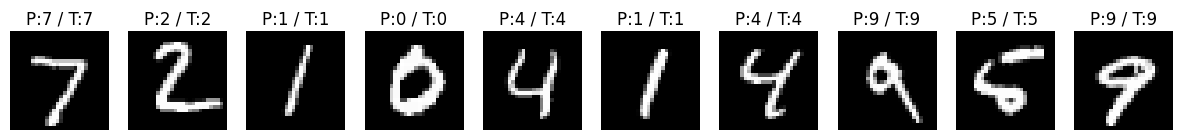

In [ ]:
plt.figure(figsize=(15, 3))

# first 10 test results
for i, (img, pred, actual) in enumerate(zip(x_test[:10], y_pred[:10], y_test[:10])):
    plt.subplot(1, 10, i + 1)
    plt.imshow(img.reshape(28, 28), cmap='gray')
    plt.title(f"P:{pred} / T:{actual}")
    plt.axis('off')

plt.show()


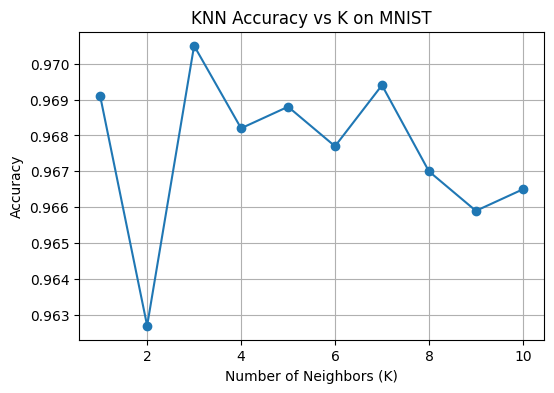

In [ ]:
k_values = range(1, 11)
accuracies = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(x_train, y_train)
    y_temp_pred = knn_temp.predict(x_test)
    acc = accuracy_score(y_test, y_temp_pred)
    accuracies.append(acc)

plt.figure(figsize=(6, 4))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K on MNIST")
plt.grid(True)
plt.show()
